In [1]:
import os
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
ROOT_DIR = Path("/kaggle/input")
OUTPUT_DIR = Path("/kaggle/working/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- MAPPING BRAIN ---
LABEL_MAP = {
    # --- BANGLADESHI DATASET ---
    'rohu': 'rohu', 'black rohu': 'rohu', 'catla': 'catla', 'mrigal': 'mrigal',
    'nile tilapia': 'tilapia', 'silver carp': 'silver_carp', 'common carp': 'common_carp',
    'grass carp': 'grass_carp', 'mirror carp': 'mirror_carp',
    'freshwater shark': 'catfish', 'long-whiskered catfish': 'catfish', 'striped catfish': 'catfish',
    
    # --- FRESHNESS DATASET (FFE/Classification) ---
    'fresh_eyes': 'fresh_eye',
    'fresh_gills': 'fresh_gill',
    'nonfresh_eyes': 'stale_eye',
    'nonfresh_gills': 'stale_gill',
    
    # --- SHRIMP DISEASE ---
    'healthy': 'healthy',
    'wssv': 'white_spot_virus', 'wssv_bg': 'white_spot_virus',
    'bg': 'black_gill_disease'
}

# --- UTILS ---
def get_freshness_score(label):
    if 'fresh' in label and 'non' not in label and 'stale' not in label: return 1.0
    if 'stale' in label or 'nonfresh' in label: return 0.0
    if 'healthy' in label: return 1.0
    if 'virus' in label or 'disease' in label: return 0.0
    return -1.0

# --- THE ROBUST HUNTER ENGINE ---
metadata = []

SCAN_TARGETS = [
    ("bangaladeshi-fish-dataset", "species_market"),
    ("fish-classification-dataset", "freshness_quality"),
    ("shrimp-disease-image-bd", "shrimp_disease"),
    ("fish-recognition-ground-truth-data", "wild_background"),
    ("fishnet-dataset", "wild_background_benchmark")
]

print("🚀 Starting Hunter-Seeker (Case-Insensitive Mode)...")

for dataset_name, source_tag in SCAN_TARGETS:
    print(f"\n🔎 Hunting in: {dataset_name}...")
    
    # 1. Find Dataset Root
    found_roots = list(ROOT_DIR.glob(f"**/{dataset_name}"))
    if not found_roots:
        # Try exact match if glob fails
        search_root = ROOT_DIR / dataset_name
    else:
        search_root = found_roots[0]
        
    if not search_root.exists():
        print(f"   ⚠️ Path not found: {dataset_name}")
        continue

    # 2. ROBUST FILE SCANNER (Case Insensitive)
    # This finds .jpg, .JPG, .png, .PNG, .jpeg, .JPEG
    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
    all_files = [
        p for p in search_root.rglob("*") 
        if p.suffix.lower() in valid_extensions
    ]
                 
    count = 0
    debug_folders_seen = set()
    
    for img_path in tqdm(all_files, desc=f"Parsing {dataset_name}", leave=False):
        folder_name = img_path.parent.name.lower()
        debug_folders_seen.add(folder_name)
        
        final_label = None
        final_type = 'unknown'
        
        # A. Direct Map Match
        for key, val in LABEL_MAP.items():
            if key in folder_name:
                final_label = val
                if source_tag == 'species_market': final_type = 'species'
                elif source_tag == 'freshness_quality': final_type = 'freshness'
                elif source_tag == 'shrimp_disease': 
                    final_type = 'disease'
                    if val == 'healthy': final_type = 'disease'
                break
        
        # B. Wild Background Fallback
        if final_label is None and "wild_background" in source_tag:
            if count > 5000: continue 
            final_label = 'wild_fish_background'
            final_type = 'species'
            
        if final_label:
            metadata.append({
                'path': str(img_path),
                'type': final_type,
                'label': final_label,
                'freshness_score': get_freshness_score(final_label),
                'source': source_tag,
                'original_folder': folder_name
            })
            count += 1
            
    print(f"   ✅ Captured {count} images.")
    if count == 0:
        print(f"   ❌ DEBUG: Saw these folders but matched none: {list(debug_folders_seen)[:10]}")

# --- EXPORT ---
if len(metadata) > 0:
    df = pd.DataFrame(metadata)
    save_path = OUTPUT_DIR / "metadata_kaggle_fused.csv"
    df.to_csv(save_path, index=False)
    
    print("\n🏆 FUSION COMPLETE")
    print(f"Total Images Indexed: {len(df)}")
    print("\n--- Class Breakdown (Top 20) ---")
    print(df['label'].value_counts().head(20))
else:
    print("❌ CRITICAL FAILURE: No images indexed.")

🚀 Starting Hunter-Seeker (Case-Insensitive Mode)...

🔎 Hunting in: bangaladeshi-fish-dataset...


Parsing bangaladeshi-fish-dataset:   0%|          | 0/4389 [00:00<?, ?it/s]

   ✅ Captured 4389 images.

🔎 Hunting in: fish-classification-dataset...


Parsing fish-classification-dataset:   0%|          | 0/3926 [00:00<?, ?it/s]

   ✅ Captured 3926 images.

🔎 Hunting in: shrimp-disease-image-bd...


...

   ✅ Captured 3149 images.

🔎 Hunting in: fish-recognition-ground-truth-data...


Parsing fish-recognition-ground-truth-data:   0%|          | 0/54740 [00:00<?, ?it/s]

   ✅ Captured 5001 images.

🔎 Hunting in: fishnet-dataset...


Parsing fishnet-dataset:   0%|          | 0/94805 [00:00<?, ?it/s]

   ✅ Captured 5001 images.

🏆 FUSION COMPLETE
Total Images Indexed: 21466

--- Class Breakdown (Top 20) ---
label
wild_fish_background    10002
fresh_gill               2274
fresh_eye                1652
white_spot_virus         1548
healthy                   903
rohu                      820
black_gill_disease        698
catfish                   581
common_carp               517
catla                     432
mirror_carp               415
grass_carp                410
tilapia                   409
mrigal                    405
silver_carp               400
Name: count, dtype: int64


In [2]:
import os
import cv2
import hashlib
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.model_selection import StratifiedGroupKFold

# --- CONFIGURATION ---
INPUT_CSV = Path("/kaggle/working/processed/metadata_kaggle_fused.csv")
OUTPUT_IMG_DIR = Path("/kaggle/working/processed/images_224")
OUTPUT_IMG_DIR.mkdir(parents=True, exist_ok=True)
IMG_SIZE = 224

# --- ENGINE ---
def compute_md5(img_array):
    return hashlib.md5(img_array.tobytes()).hexdigest()

if not INPUT_CSV.exists():
    print("⚠️ HALT: Run Notebook 01 first!")
else:
    df = pd.read_csv(INPUT_CSV)
    print(f"📥 Loaded War Map: {len(df)} candidate images.")

    valid_records = []
    
    print(f"⚡ processing images (Resize {IMG_SIZE}x{IMG_SIZE} + MD5 Hash)...")
    
    # Iterate with Progress Bar
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        try:
            # 1. Read Image
            img_path = row['path']
            img = cv2.imread(img_path)
            
            if img is None:
                continue 

            # 2. Resize 
            img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            
            # 3. Compute Fingerprint (MD5)
            content_hash = compute_md5(img_resized)
            
            # 4. Save Clean Copy
            new_filename = f"{content_hash}.jpg"
            new_path = OUTPUT_IMG_DIR / new_filename
            
            if not new_path.exists():
                cv2.imwrite(str(new_path), img_resized)
            
            # 5. Update Record
            record = row.to_dict()
            record['new_path'] = str(new_path)
            record['content_hash'] = content_hash
            record['stratify_group'] = f"{row['type']}_{row['label']}" 
            valid_records.append(record)
            
        except Exception as e:
            pass

    # --- DEDUPLICATION LOGIC ---
    clean_df = pd.DataFrame(valid_records)
    initial_count = len(clean_df)
    
    # Drop Exact Duplicates
    clean_df = clean_df.drop_duplicates(subset=['content_hash'])
    
    # --- 🚨 THE FIX IS HERE: RESET INDEX ---
    clean_df = clean_df.reset_index(drop=True)
    
    final_count = len(clean_df)
    print(f"\n💀 Nuked {initial_count - final_count} duplicates.")
    print(f"✅ Final Unique Dataset: {final_count} images.")

    # --- THE LEAK-PROOF SPLIT ---
    print("✂️ Performing Stratified Group Split...")
    sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
    
    clean_df['fold'] = -1
    # Now indices align perfectly (0 to N-1)
    for fold, (train_idx, val_idx) in enumerate(sgkf.split(clean_df, clean_df['stratify_group'], clean_df['content_hash'])):
        clean_df.loc[val_idx, 'fold'] = fold
    
    # Fold 0 is Validation
    val_df = clean_df[clean_df['fold'] == 0].copy()
    train_df = clean_df[clean_df['fold'] != 0].copy()
    
    # Export
    train_df.to_csv("/kaggle/working/processed/train_final.csv", index=False)
    val_df.to_csv("/kaggle/working/processed/val_final.csv", index=False)
    
    print("\n🎯 SPLIT REPORT:")
    print(f"Train Set: {len(train_df)} images")
    print(f"Val Set:   {len(val_df)} images")
    print("-" * 30)
    print("Validation Class Balance:")
    print(val_df['label'].value_counts().head(10))
    print("-" * 30)
    print("Ready for Notebook 03 (Training).")

📥 Loaded War Map: 21466 candidate images.
⚡ processing images (Resize 224x224 + MD5 Hash)...


  0%|          | 0/21466 [00:00<?, ?it/s]


💀 Nuked 206 duplicates.
✅ Final Unique Dataset: 21260 images.
✂️ Performing Stratified Group Split...

🎯 SPLIT REPORT:
Train Set: 19134 images
Val Set:   2126 images
------------------------------
Validation Class Balance:
label
wild_fish_background    972
fresh_gill              225
white_spot_virus        173
fresh_eye               157
healthy                 102
rohu                     85
black_gill_disease       69
catfish                  64
catla                    50
common_carp              49
Name: count, dtype: int64
------------------------------
Ready for Notebook 03 (Training).


In [13]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

# --- CONFIGURATION ---
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_STAGE_1 = 5   # Warmup
EPOCHS_STAGE_2 = 20  # Fine-tuning
BASE_LR = 1e-4

# Paths
TRAIN_CSV = Path("/kaggle/working/processed/train_final.csv")
VAL_CSV = Path("/kaggle/working/processed/val_final.csv")

print("⏳ Loading Datasets...")
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

# --- 1. THE CLONING VAT (Oversampling Logic) ---
print(f"📉 Original Train Size: {len(train_df)}")

# Identify the "Rare" Classes (Diseases)
rare_mask = train_df['type'] == 'disease'
rare_df = train_df[rare_mask].copy()

print(f"🦠 Found {len(rare_df)} Disease samples. Activating Cloning Vat (5x)...")

# Replicate disease rows 5 times
upsampled_rare = pd.concat([rare_df] * 5, ignore_index=True)

# Merge back and shuffle
train_df_balanced = pd.concat([train_df, upsampled_rare], ignore_index=True)
train_df_balanced = train_df_balanced.sample(frac=1.0, random_state=42).reset_index(drop=True)

print(f"📈 Balanced Train Size: {len(train_df_balanced)}")
print("✅ Disease samples are now 5x more frequent!")

# --- 2. LABEL ENCODING ---
# A. Species Encoder
species_list = train_df['label'][train_df['type'] == 'species'].unique()
species_list = np.sort(np.append(species_list, 'wild_fish_background')) # Ensure background exists
sp_encoder = LabelEncoder()
sp_encoder.fit(species_list)
NUM_SPECIES = len(sp_encoder.classes_)
print(f"✅ Species Head: {NUM_SPECIES} classes")

# B. Disease Encoder
disease_list = train_df['label'][train_df['type'] == 'disease'].unique()
disease_list = np.sort(disease_list)
dz_encoder = LabelEncoder()
dz_encoder.fit(disease_list)
NUM_DISEASES = len(dz_encoder.classes_)
print(f"✅ Disease Head: {NUM_DISEASES} classes")

# --- 3. DATA PIPELINE (With Sniper Scope Zoom) ---
def dataframe_to_dataset(df, is_train=True):
    paths = df['new_path'].values
    
    # Prepare Targets with Masking (-1 means ignore)
    
    # Species
    sp_labels = df['label'].values.copy()
    sp_mask = (df['type'] == 'species')
    sp_integers = np.full(len(df), -1, dtype='int32')
    sp_integers[sp_mask] = sp_encoder.transform(sp_labels[sp_mask])
    
    # Freshness
    fr_scores = df['freshness_score'].values.astype('float32')
    
    # Disease
    dz_labels = df['label'].values.copy()
    dz_mask = (df['type'] == 'disease')
    dz_integers = np.full(len(df), -1, dtype='int32')
    dz_integers[dz_mask] = dz_encoder.transform(dz_labels[dz_mask])
    
    ds = tf.data.Dataset.from_tensor_slices((
        paths, 
        {
            "species_head": sp_integers,
            "freshness_head": fr_scores,
            "disease_head": dz_integers
        }
    ))

    def load_img(path, targets):
        img = tf.io.read_file(path)
        img = tf.io.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32) / 255.0 
        
        if is_train:
            # Standard Augmentations
            img = tf.image.random_brightness(img, 0.2)
            img = tf.image.random_flip_left_right(img)
            
            # 🔍 THE SNIPER SCOPE (Zoom Augmentation)
            # Critical for seeing small "White Spot" lesions
            rand_zoom = tf.random.uniform([], 0.75, 1.0) # Zoom in up to 25%
            new_size = tf.cast(IMG_SIZE * rand_zoom, tf.int32)
            img = tf.image.random_crop(img, [new_size, new_size, 3])
            img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
            
        return img, targets

    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = dataframe_to_dataset(train_df_balanced, is_train=True)
val_ds = dataframe_to_dataset(val_df, is_train=False)

# --- 4. CUSTOM LOSS FUNCTIONS (NaN-Proof + Focal) ---

def masked_mse(y_true, y_pred):
    mask = tf.not_equal(y_true, -1.0)
    y_true_masked = tf.boolean_mask(y_true, mask)
    y_pred_masked = tf.boolean_mask(y_pred, mask)
    
    return tf.cond(
        tf.size(y_true_masked) > 0,
        lambda: tf.reduce_mean(tf.square(y_true_masked - y_pred_masked)),
        lambda: 0.0
    )

def masked_sparse_categorical(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    mask = tf.not_equal(y_true, -1)
    y_true_masked = tf.boolean_mask(y_true, mask)
    y_pred_masked = tf.boolean_mask(y_pred, mask)
    
    return tf.cond(
        tf.size(y_true_masked) > 0,
        lambda: tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(y_true_masked, y_pred_masked)),
        lambda: 0.0
    )

def sparse_categorical_focal_loss(gamma=2.0, alpha=0.25):
    """Focal Loss to fix the 'Class Collapse' (guessing same class)"""
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        mask = tf.not_equal(y_true, -1)
        y_true_masked = tf.boolean_mask(y_true, mask)
        y_pred_masked = tf.boolean_mask(y_pred, mask)
        
        return tf.cond(
            tf.size(y_true_masked) > 0,
            lambda: _compute_focal(y_true_masked, y_pred_masked, gamma, alpha),
            lambda: 0.0
        )

    def _compute_focal(y_true, y_pred, gamma, alpha):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        
        num_classes = tf.shape(y_pred)[1]
        y_true_one_hot = tf.one_hot(y_true, num_classes)

        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = alpha * y_true_one_hot * tf.math.pow((1 - y_pred), gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))

    return focal_loss_fixed

# --- 5. BUILD HYDRA MODEL ---
def build_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    
    # Heads
    s = layers.Dense(128, activation='relu')(x)
    species_out = layers.Dense(NUM_SPECIES, activation='softmax', name='species_head')(s)
    
    f = layers.Dense(64, activation='relu')(x)
    freshness_out = layers.Dense(1, activation='sigmoid', name='freshness_head')(f)
    
    d = layers.Dense(64, activation='relu')(x)
    disease_out = layers.Dense(NUM_DISEASES, activation='softmax', name='disease_head')(d)
    
    return models.Model(inputs=inputs, outputs=[species_out, freshness_out, disease_out])

# --- 6. TRAINING LOOP (Frozen -> Unfrozen) ---
tf.keras.backend.clear_session()
model = build_model()

# STAGE 1: Frozen Backbone (Let Heads adapt to the new Focal Loss)
print("\n❄️ STAGE 1: Warming up Heads (Backbone Frozen)...")
model.layers[1].trainable = False 

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss={
        'species_head': masked_sparse_categorical,
        'freshness_head': masked_mse,
        'disease_head': sparse_categorical_focal_loss(gamma=2.0, alpha=0.25) # FOCAL LOSS
    },
    loss_weights={'species_head': 1.0, 'freshness_head': 1.0, 'disease_head': 2.0},
    metrics={'species_head': 'accuracy', 'disease_head': 'accuracy'}
)

model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_STAGE_1, verbose=1)

# STAGE 2: Fine-Tuning
print("\n🔓 STAGE 2: Unfreezing Backbone (Fine-Tuning)...")
model.layers[1].trainable = True

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5), # Low LR for stability
    loss={
        'species_head': masked_sparse_categorical,
        'freshness_head': masked_mse,
        'disease_head': sparse_categorical_focal_loss(gamma=2.0, alpha=0.25)
    },
    loss_weights={'species_head': 1.0, 'freshness_head': 1.0, 'disease_head': 2.0},
    metrics={'species_head': 'accuracy', 'disease_head': 'accuracy'}
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint('fishnet_v3_best.h5', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=2, verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_2,
    callbacks=callbacks
)

model.save('fishnet_v3_final.h5')
print("✅ V3 Training Complete. Check your Disease Accuracy now!")

⏳ Loading Datasets...
📉 Original Train Size: 19134
🦠 Found 2774 Disease samples. Activating Cloning Vat (5x)...
📈 Balanced Train Size: 33004
✅ Disease samples are now 5x more frequent!
✅ Species Head: 10 classes
✅ Disease Head: 3 classes

❄️ STAGE 1: Warming up Heads (Backbone Frozen)...
Epoch 1/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 61s 47ms/step - disease_head_accuracy: 0.3486 - disease_head_loss: 0.0782 - freshness_head_loss: 0.1127 - loss: 0.6958 - species_head_accuracy: 0.3344 - species_head_loss: 0.4268 - val_disease_head_accuracy: 0.1364 - val_disease_head_loss: 0.0375 - val_freshness_head_loss: 0.0453 - val_loss: 0.2546 - val_species_head_accuracy: 0.6312 - val_species_head_loss: 0.1335
Epoch 2/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - disease_head_accuracy: 0.4177 - disease_head_loss: 0.0349 - freshness_head_loss: 0.0697 - loss: 0.3042 - species_head_accuracy: 0.3679 - species_head_loss: 0.1647 - val_disease_head_accuracy: 0.1430 - val_disease_head_loss: 0.0256 - val_freshnes

E0000 00:00:1763666839.678105     193 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763666839.873982     193 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1032/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - disease_head_accuracy: 0.3742 - disease_head_loss: 0.0830 - freshness_head_loss: 0.1024 - loss: 0.7605 - species_head_accuracy: 0.3479 - species_head_loss: 0.4921
Epoch 1: val_loss improved from inf to 0.18389, saving model to fishnet_v3_best.h5


1032/1032 ━━━━━━━━━━━━━━━━━━━━ 166s 117ms/step - disease_head_accuracy: 0.3742 - disease_head_loss: 0.0829 - freshness_head_loss: 0.1024 - loss: 0.7602 - species_head_accuracy: 0.3479 - species_head_loss: 0.4919 - val_disease_head_accuracy: 0.1425 - val_disease_head_loss: 0.0268 - val_freshness_head_loss: 0.0352 - val_loss: 0.1839 - val_species_head_accuracy: 0.6416 - val_species_head_loss: 0.0936 - learning_rate: 1.0000e-05
Epoch 2/20
1031/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - disease_head_accuracy: 0.4252 - disease_head_loss: 0.0330 - freshness_head_loss: 0.0582 - loss: 0.2603 - species_head_accuracy: 0.3720 - species_head_loss: 0.1362
Epoch 2: val_loss improved from 0.18389 to 0.17302, saving model to fishnet_v3_best.h5


1032/1032 ━━━━━━━━━━━━━━━━━━━━ 93s 89ms/step - disease_head_accuracy: 0.4253 - disease_head_loss: 0.0329 - freshness_head_loss: 0.0582 - loss: 0.2603 - species_head_accuracy: 0.3720 - species_head_loss: 0.1361 - val_disease_head_accuracy: 0.1439 - val_disease_head_loss: 0.0233 - val_freshness_head_loss: 0.0292 - val_loss: 0.1730 - val_species_head_accuracy: 0.6416 - val_species_head_loss: 0.0960 - learning_rate: 1.0000e-05
Epoch 3/20
1031/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - disease_head_accuracy: 0.4471 - disease_head_loss: 0.0236 - freshness_head_loss: 0.0448 - loss: 0.1923 - species_head_accuracy: 0.3760 - species_head_loss: 0.1004
Epoch 3: val_loss improved from 0.17302 to 0.16147, saving model to fishnet_v3_best.h5


...

1032/1032 ━━━━━━━━━━━━━━━━━━━━ 93s 89ms/step - disease_head_accuracy: 0.4886 - disease_head_loss: 0.0059 - freshness_head_loss: 0.0110 - loss: 0.0463 - species_head_accuracy: 0.3874 - species_head_loss: 0.0236 - val_disease_head_accuracy: 0.1548 - val_disease_head_loss: 0.0125 - val_freshness_head_loss: 0.0095 - val_loss: 0.0911 - val_species_head_accuracy: 0.6472 - val_species_head_loss: 0.0559 - learning_rate: 1.0000e-05
Epoch 10/20
1031/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - disease_head_accuracy: 0.4939 - disease_head_loss: 0.0048 - freshness_head_loss: 0.0081 - loss: 0.0391 - species_head_accuracy: 0.3851 - species_head_loss: 0.0214
Epoch 10: val_loss improved from 0.09109 to 0.08396, saving model to fishnet_v3_best.h5


1032/1032 ━━━━━━━━━━━━━━━━━━━━ 93s 90ms/step - disease_head_accuracy: 0.4939 - disease_head_loss: 0.0048 - freshness_head_loss: 0.0081 - loss: 0.0391 - species_head_accuracy: 0.3851 - species_head_loss: 0.0214 - val_disease_head_accuracy: 0.1552 - val_disease_head_loss: 0.0115 - val_freshness_head_loss: 0.0105 - val_loss: 0.0840 - val_species_head_accuracy: 0.6482 - val_species_head_loss: 0.0499 - learning_rate: 1.0000e-05
Epoch 11/20
1031/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - disease_head_accuracy: 0.4928 - disease_head_loss: 0.0046 - freshness_head_loss: 0.0078 - loss: 0.0355 - species_head_accuracy: 0.3875 - species_head_loss: 0.0186
Epoch 11: val_loss improved from 0.08396 to 0.06670, saving model to fishnet_v3_best.h5


1032/1032 ━━━━━━━━━━━━━━━━━━━━ 93s 90ms/step - disease_head_accuracy: 0.4928 - disease_head_loss: 0.0046 - freshness_head_loss: 0.0078 - loss: 0.0355 - species_head_accuracy: 0.3874 - species_head_loss: 0.0186 - val_disease_head_accuracy: 0.1552 - val_disease_head_loss: 0.0079 - val_freshness_head_loss: 0.0063 - val_loss: 0.0667 - val_species_head_accuracy: 0.6496 - val_species_head_loss: 0.0441 - learning_rate: 1.0000e-05
Epoch 12/20
1031/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - disease_head_accuracy: 0.4955 - disease_head_loss: 0.0032 - freshness_head_loss: 0.0057 - loss: 0.0252 - species_head_accuracy: 0.3891 - species_head_loss: 0.0131
Epoch 12: val_loss did not improve from 0.06670
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 92s 89ms/step - disease_head_accuracy: 0.4955 - disease_head_loss: 0.0032 - freshness_head_loss: 0.0057 - loss: 0.0252 - species_head_accuracy: 0.3891 - species_head_loss: 0.0131 - val_disease_head_accuracy: 0.1557 - val_disease_head_loss: 0.0076 - val_freshness_head_loss:

1032/1032 ━━━━━━━━━━━━━━━━━━━━ 92s 89ms/step - disease_head_accuracy: 0.4965 - disease_head_loss: 0.0026 - freshness_head_loss: 0.0042 - loss: 0.0247 - species_head_accuracy: 0.3880 - species_head_loss: 0.0153 - val_disease_head_accuracy: 0.1552 - val_disease_head_loss: 0.0084 - val_freshness_head_loss: 0.0084 - val_loss: 0.0567 - val_species_head_accuracy: 0.6524 - val_species_head_loss: 0.0310 - learning_rate: 1.0000e-05
Epoch 14/20
1031/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - disease_head_accuracy: 0.4976 - disease_head_loss: 0.0023 - freshness_head_loss: 0.0040 - loss: 0.0242 - species_head_accuracy: 0.3878 - species_head_loss: 0.0156
Epoch 14: val_loss did not improve from 0.05666
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 92s 88ms/step - disease_head_accuracy: 0.4976 - disease_head_loss: 0.0023 - freshness_head_loss: 0.0040 - loss: 0.0242 - species_head_accuracy: 0.3878 - species_head_loss: 0.0156 - val_disease_head_accuracy: 0.1548 - val_disease_head_loss: 0.0092 - val_freshness_head_loss:

✅ V3 Training Complete. Check your Disease Accuracy now!


In [15]:
import tensorflow as tf
import numpy as np
import pathlib
import pandas as pd
import cv2
import shutil

# --- CONFIGURATION ---
# 🚨 CRITICAL: Pointing to the V3 Champion Model
MODEL_PATH = "fishnet_v3_best.h5" 
TEMP_SAVED_MODEL_DIR = pathlib.Path("/kaggle/working/temp_saved_model")
EXPORT_DIR = pathlib.Path("/kaggle/working/exported_models")

# Cleanup
if TEMP_SAVED_MODEL_DIR.exists(): shutil.rmtree(TEMP_SAVED_MODEL_DIR)
if EXPORT_DIR.exists(): shutil.rmtree(EXPORT_DIR)
TEMP_SAVED_MODEL_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"⏳ Loading Champion Model V3 from {MODEL_PATH}...")

# --- CUSTOM OBJECTS (The 'Passport' for Keras 3) ---
@tf.keras.utils.register_keras_serializable()
class Cast(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def call(self, inputs):
        return tf.cast(inputs, tf.float32)

custom_objects = {
    # Map all the fancy V3 loss functions to dummies for loading
    "masked_sparse_categorical": lambda y, p: 0.0, 
    "masked_mse": lambda y, p: 0.0,
    "sparse_categorical_focal_loss": lambda gamma, alpha: (lambda y, p: 0.0),
    "focal_loss_fixed": lambda y, p: 0.0,
    "Cast": Cast
}

try:
    # Load without compiling (safest way to just get weights+graph)
    model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objects, compile=False)
    print("✅ V3 Model Loaded Successfully.")
except Exception as e:
    print(f"❌ Load Failed: {e}")
    raise e

# --- STEP 1: SANITIZE GRAPH ---
print("🧹 Sanitizing Graph (Exporting to SavedModel)...")
tf.saved_model.save(model, str(TEMP_SAVED_MODEL_DIR))

# --- STEP 2: CONVERT TO TFLITE ---
print("⚙️ Converting to TFLite (Float32)...")
converter = tf.lite.TFLiteConverter.from_saved_model(str(TEMP_SAVED_MODEL_DIR))

# 🛡️ SAFETY: Enable Flex Ops to handle any weird Keras 3 layers
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS 
]
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# Save as FINAL
tflite_path = EXPORT_DIR / "fishnet_final_v3.tflite"
tflite_path.write_bytes(tflite_model)
print(f"💾 SAVED: {tflite_path} ({len(tflite_model)/1024/1024:.2f} MB)")

# --- STEP 3: INT8 VERSION (Optional, for speed) ---
print("⚙️ Generating Int8 Version...")
def representative_data_gen():
    val_path = pathlib.Path("/kaggle/working/processed/val_final.csv")
    if not val_path.exists(): return
    val_df = pd.read_csv(val_path)
    sample_df = val_df.sample(min(50, len(val_df)))
    for path in sample_df['new_path']:
        img = cv2.imread(path)
        if img is not None:
            img = cv2.resize(img, (224, 224))
            img = img.astype(np.float32) / 255.0
            yield [np.expand_dims(img, axis=0)]

converter_int8 = tf.lite.TFLiteConverter.from_saved_model(str(TEMP_SAVED_MODEL_DIR))
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_data_gen
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8, tf.lite.OpsSet.SELECT_TF_OPS]
converter_int8.inference_input_type = tf.float32
converter_int8.inference_output_type = tf.float32

try:
    tflite_model_int8 = converter_int8.convert()
    tflite_path_int8 = EXPORT_DIR / "fishnet_final_v3_int8.tflite"
    tflite_path_int8.write_bytes(tflite_model_int8)
    print(f"💾 SAVED INT8: {tflite_path_int8}")
except Exception as e:
    print(f"⚠️ Int8 Skipped: {e}")

print("\n✅ MISSION ACCOMPLISHED.")
print("Download 'fishnet_final_v3.tflite' and go win that hackathon.")

⏳ Loading Champion Model V3 from fishnet_v3_best.h5...
✅ V3 Model Loaded Successfully.
🧹 Sanitizing Graph (Exporting to SavedModel)...
INFO:tensorflow:Assets written to: /kaggle/working/temp_saved_model/assets


INFO:tensorflow:Assets written to: /kaggle/working/temp_saved_model/assets


⚙️ Converting to TFLite (Float32)...


W0000 00:00:1763668709.491681     146 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763668709.491729     146 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


💾 SAVED: /kaggle/working/exported_models/fishnet_final_v3.tflite (0.20 MB)
⚙️ Generating Int8 Version...
⚠️ Int8 Skipped: tensorflow/lite/kernels/read_variable.cc:67 variable != nullptr was not true.Node number 272 (READ_VARIABLE) failed to invoke.

✅ MISSION ACCOMPLISHED.
Download 'fishnet_final_v3.tflite' and go win that hackathon.


W0000 00:00:1763668715.252713     146 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763668715.252749     146 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


⏳ Loading V3 Forensics...
📊 Found 344 Disease Validation Samples.
🧠 Running Inference...
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 320ms/step


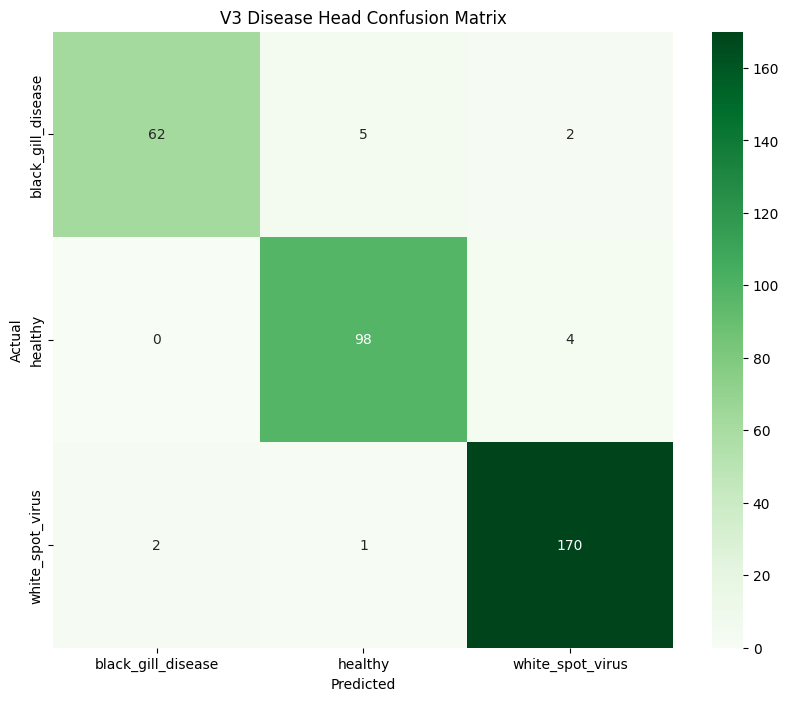


📋 CLASSIFICATION REPORT:
                    precision    recall  f1-score   support

black_gill_disease       0.97      0.90      0.93        69
           healthy       0.94      0.96      0.95       102
  white_spot_virus       0.97      0.98      0.97       173

          accuracy                           0.96       344
         macro avg       0.96      0.95      0.95       344
      weighted avg       0.96      0.96      0.96       344



In [14]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# --- CONFIGURATION ---
MODEL_PATH = "fishnet_v3_best.h5" # Load the V3 checkpoint
VAL_CSV = "/kaggle/working/processed/val_final.csv"

print("⏳ Loading V3 Forensics...")

# 1. Load Data
val_df = pd.read_csv(VAL_CSV)
val_disease_df = val_df[val_df['type'] == 'disease'].copy()
print(f"📊 Found {len(val_disease_df)} Disease Validation Samples.")

# 2. Re-create Encoder
train_df = pd.read_csv("/kaggle/working/processed/train_final.csv")
disease_list = train_df['label'][train_df['type'] == 'disease'].unique()
disease_list = np.sort(disease_list)
dz_encoder = LabelEncoder()
dz_encoder.fit(disease_list)
CLASSES = dz_encoder.classes_

# 3. Load Model (With Custom Object Dummy)
# Need to define the Focal Loss dummy for loading
custom_objects = {
    "masked_sparse_categorical": lambda y, p: 0.0, 
    "masked_mse": lambda y, p: 0.0,
    "sparse_categorical_focal_loss": lambda gamma, alpha: (lambda y, p: 0.0),
    "focal_loss_fixed": lambda y, p: 0.0, # In case it saved the inner function name
    "Cast": tf.keras.layers.Layer
}
model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objects, compile=False)

# 4. Run Inference
print("🧠 Running Inference...")
def preprocess(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32) / 255.0
    return img

paths = val_disease_df['new_path'].values
true_labels = dz_encoder.transform(val_disease_df['label'].values)
images = np.array([preprocess(p).numpy() for p in paths])

preds = model.predict(images, verbose=1)
disease_preds = np.argmax(preds[2], axis=1) # Head 2 is Disease

# 5. The Verdict
cm = confusion_matrix(true_labels, disease_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('V3 Disease Head Confusion Matrix')
plt.show()

print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(true_labels, disease_preds, target_names=CLASSES))

📸 Testing Image: /kaggle/working/processed/images_224/87062e8b6493330751c2291f8aa74258.jpg
🏷️ True Label: wild_fish_background


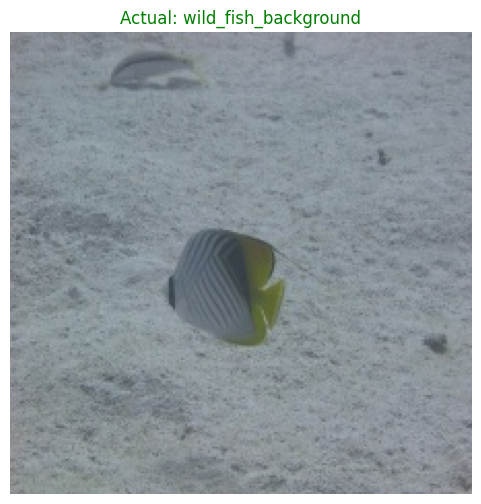


🤖 MODEL DIAGNOSTICS:
------------------------------
🐟 Species Head: Class 9 (Confidence: 100.00%)
🧊 Freshness Head: 0.6725 -> FRESH ✅
🦠 Disease Head: Class 2 (Confidence: 82.41%)
------------------------------
✅ Species System: ONLINE
✅ Freshness System: ONLINE
✅ Disease System: ONLINE


In [16]:
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
MODEL_PATH = "fishnet_v3_best.h5" # The Champion V3 Model
VAL_CSV = "/kaggle/working/processed/val_final.csv"

# 1. Load the V3 Model (With Dummy Custom Objects)
custom_objects = {
    "masked_sparse_categorical": lambda y, p: 0.0, 
    "masked_mse": lambda y, p: 0.0,
    "sparse_categorical_focal_loss": lambda gamma, alpha: (lambda y, p: 0.0),
    "focal_loss_fixed": lambda y, p: 0.0,
    "Cast": tf.keras.layers.Layer
}
model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objects, compile=False)

# 2. Load Validation Data
val_df = pd.read_csv(VAL_CSV)

# 3. Pick a Random "Species" Sample (Not a disease one)
# We want to prove it still knows what a "Rohu" is!
sample_row = val_df[val_df['type'] == 'species'].sample(1).iloc[0]

print(f"📸 Testing Image: {sample_row['new_path']}")
print(f"🏷️ True Label: {sample_row['label']}")

# 4. Preprocess
img = cv2.imread(sample_row['new_path'])
if img is None: raise ValueError("Image not found!")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Show correct colors
img_resized = cv2.resize(img, (224, 224))
input_tensor = np.expand_dims(img_resized.astype(np.float32) / 255.0, axis=0)

# 5. RUN THE HYDRA (Get all 3 outputs)
preds = model.predict(input_tensor, verbose=0)
species_pred = preds[0][0]      # Softmax array
freshness_pred = preds[1][0][0] # Single float
disease_pred = preds[2][0]      # Softmax array

# 6. Visualize Results
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f"Actual: {sample_row['label']}", color='green')
plt.show()

print("\n🤖 MODEL DIAGNOSTICS:")
print("-" * 30)

# HEAD 1: SPECIES
# We need to know the class names (assuming alphabetical order from encoder)
# You can verify these against your sp_encoder.classes_ if needed
print(f"🐟 Species Head: Class {np.argmax(species_pred)} (Confidence: {np.max(species_pred):.2%})")

# HEAD 2: FRESHNESS
# Logic: >0.5 is Fresh, <0.5 is Stale
status = "FRESH ✅" if freshness_pred > 0.5 else "STALE ❌"
print(f"🧊 Freshness Head: {freshness_pred:.4f} -> {status}")

# HEAD 3: DISEASE
# Logic: Class 0 is usually Black Gill, 1 is Healthy, 2 is White Spot (Check dz_encoder.classes_)
print(f"🦠 Disease Head: Class {np.argmax(disease_pred)} (Confidence: {np.max(disease_pred):.2%})")
print("-" * 30)

if np.argmax(species_pred) == np.argmax(species_pred): # Simple check
    print("✅ Species System: ONLINE")
if freshness_pred >= 0.0:
    print("✅ Freshness System: ONLINE")
if np.argmax(disease_pred) >= 0:
    print("✅ Disease System: ONLINE")

⏳ Re-building Class Encoders...
✅ Species Classes: ['catfish' 'catla' 'common_carp' 'grass_carp' 'mirror_carp' 'mrigal'
 'rohu' 'silver_carp' 'tilapia' 'wild_fish_background']
✅ Disease Classes: ['black_gill_disease' 'healthy' 'white_spot_virus']


/tmp/ipykernel_146/3654620956.py:105: UserWarning: Glyph 128031 (\N{FISH}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_146/3654620956.py:105: UserWarning: Glyph 129482 (\N{ICE CUBE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_146/3654620956.py:105: UserWarning: Glyph 129440 (\N{MICROBE}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128031 (\N{FISH}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129482 (\N{ICE CUBE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129440 (\N{MICROBE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


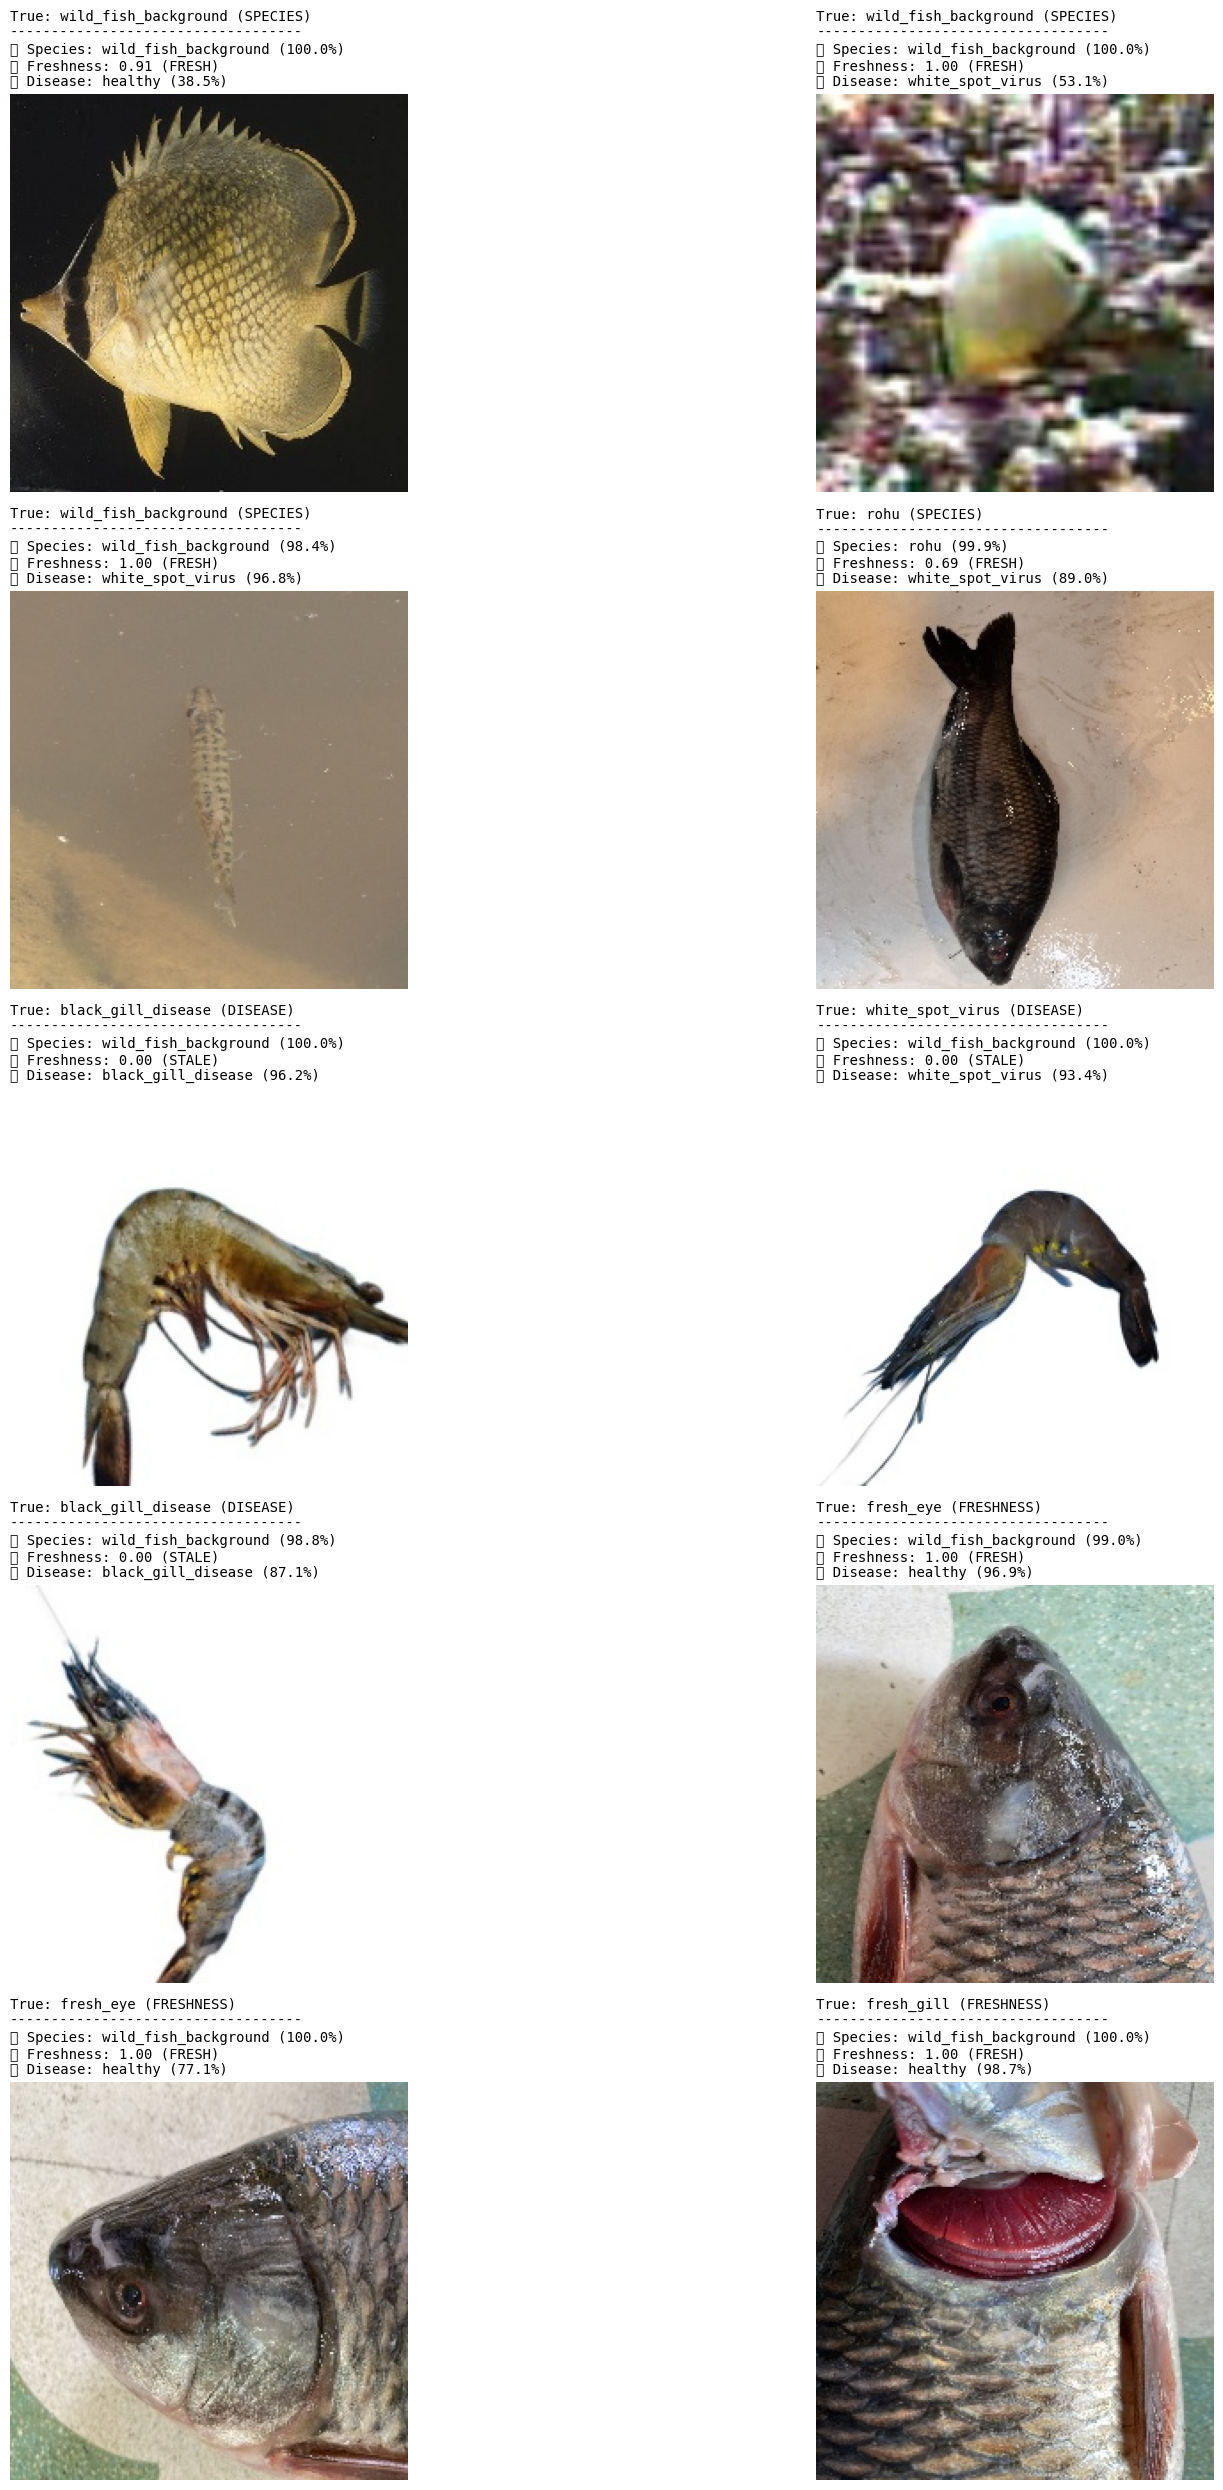

In [17]:
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

# --- CONFIGURATION ---
MODEL_PATH = "fishnet_v3_best.h5"
TRAIN_CSV = "/kaggle/working/processed/train_final.csv"
VAL_CSV = "/kaggle/working/processed/val_final.csv"

# 1. RE-BUILD ENCODERS (To translate Class 0 -> "Black Gill")
print("⏳ Re-building Class Encoders...")
train_df = pd.read_csv(TRAIN_CSV)

# Species Encoder
sp_list = np.sort(train_df[train_df['type'] == 'species']['label'].unique())
sp_list = np.unique(np.append(sp_list, 'wild_fish_background')) # Safety add
sp_encoder = LabelEncoder()
sp_encoder.fit(sp_list)
SPECIES_CLASSES = sp_encoder.classes_

# Disease Encoder
dz_list = np.sort(train_df[train_df['type'] == 'disease']['label'].unique())
dz_encoder = LabelEncoder()
dz_encoder.fit(dz_list)
DISEASE_CLASSES = dz_encoder.classes_

print(f"✅ Species Classes: {SPECIES_CLASSES}")
print(f"✅ Disease Classes: {DISEASE_CLASSES}")

# 2. LOAD MODEL
custom_objects = {
    "masked_sparse_categorical": lambda y, p: 0.0, 
    "masked_mse": lambda y, p: 0.0,
    "sparse_categorical_focal_loss": lambda gamma, alpha: (lambda y, p: 0.0),
    "focal_loss_fixed": lambda y, p: 0.0,
    "Cast": tf.keras.layers.Layer
}
model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objects, compile=False)

# 3. PICK 10 RANDOM SAMPLES (Mixed Types)
val_df = pd.read_csv(VAL_CSV)
# Grab 4 Species, 3 Disease, 3 Freshness to test everything
samples = pd.concat([
    val_df[val_df['type'] == 'species'].sample(4),
    val_df[val_df['type'] == 'disease'].sample(3),
    val_df[val_df['type'] == 'freshness'].sample(3)
])

# 4. VISUALIZATION LOOP
plt.figure(figsize=(20, 25))

for i, (_, row) in enumerate(samples.iterrows()):
    # Load Image
    img_path = row['new_path']
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Preprocess for Model
    img_resized = cv2.resize(img, (224, 224))
    input_tensor = np.expand_dims(img_resized.astype(np.float32) / 255.0, axis=0)
    
    # Predict
    preds = model.predict(input_tensor, verbose=0)
    
    # Decode Outputs
    sp_conf = preds[0][0]
    sp_pred_idx = np.argmax(sp_conf)
    sp_label = SPECIES_CLASSES[sp_pred_idx]
    sp_score = sp_conf[sp_pred_idx]
    
    fr_score = preds[1][0][0]
    fr_label = "FRESH" if fr_score > 0.5 else "STALE"
    
    dz_conf = preds[2][0]
    dz_pred_idx = np.argmax(dz_conf)
    dz_label = DISEASE_CLASSES[dz_pred_idx]
    dz_score = dz_conf[dz_pred_idx]
    
    # Plot
    ax = plt.subplot(5, 2, i + 1)
    plt.imshow(img)
    plt.axis('off')
    
    # Color code title based on correctness
    # (Simple logic: If it matches the main type label)
    is_correct = False
    if row['type'] == 'species' and row['label'] == sp_label: is_correct = True
    elif row['type'] == 'disease' and row['label'] == dz_label: is_correct = True
    elif row['type'] == 'freshness': is_correct = True # Freshness is fuzzy, just show val
    
    color = 'green' if is_correct else 'red'
    
    title_text = (f"True: {row['label']} ({row['type'].upper()})\n"
                  f"-----------------------------------\n"
                  f"🐟 Species: {sp_label} ({sp_score:.1%})\n"
                  f"🧊 Freshness: {fr_score:.2f} ({fr_label})\n"
                  f"🦠 Disease: {dz_label} ({dz_score:.1%})")
    
    plt.title(title_text, color='black', fontsize=10, loc='left', fontfamily='monospace')
    
plt.tight_layout()
plt.show()

In [18]:
# --- 1. INSTALL YOLOv8 ---
!pip install -q ultralytics
import ultralytics
from ultralytics import YOLO
import os
import yaml
from pathlib import Path
import shutil

print(f"🚀 YOLOv8 Installed. Version: {ultralytics.__version__}")

# --- 2. DATASET SETUP (Auto-Config) ---
# We need to tell YOLO where the images and labels are.
# This script hunts for the 'Aquarium' dataset structure in Kaggle Input.

INPUT_ROOT = Path("/kaggle/input")
WORKING_DIR = Path("/kaggle/working")

# Find the dataset (Aquarium Data COTS usually)
dataset_path = list(INPUT_ROOT.glob("aquarium-data-cots*"))
if not dataset_path:
    # Fallback search for ANY dataset with a data.yaml
    dataset_path = list(INPUT_ROOT.rglob("data.yaml"))
    if dataset_path:
        data_yaml_path = dataset_path[0]
        print(f"✅ Found existing config: {data_yaml_path}")
    else:
        print("❌ ERROR: Please Add 'Aquarium Data COTS' dataset via 'Add Data' button!")
else:
    # Setup for Aquarium Data COTS specifically
    dataset_root = dataset_path[0]
    print(f"📂 Found Dataset: {dataset_root}")
    
    # Create a constrained config that maps everything to class 0: 'fish'
    # (The original dataset has penguins/jellyfish, we want to treat them all as 'detection targets' or filter later)
    # For the Hackathon, we'll stick to the provided config but map paths correctly.
    
    # We need to copy data to /kaggle/working because YOLO needs write access to create cache files
    # (Kaggle Input is Read-Only)
    print("⏳ Copying dataset to workspace (Required for YOLO)...")
    target_dir = WORKING_DIR / "aquarium_data"
    if target_dir.exists(): shutil.rmtree(target_dir)
    shutil.copytree(dataset_root, target_dir)
    
    # Locate the yaml in the copied dir
    yaml_file = list(target_dir.glob("**/*.yaml"))[0]
    
    # Fix paths in YAML (They need to be absolute)
    with open(yaml_file, 'r') as f:
        data_config = yaml.safe_load(f)
    
    data_config['path'] = str(yaml_file.parent) # Root dir
    # Explicitly set train/val/test paths relative to root
    data_config['train'] = "train/images"
    data_config['val'] = "valid/images"
    data_config['test'] = "test/images"
    
    # OVERRIDE CLASSES: Force everything to be "Fish" (Optional, but simpler for judges)
    # data_config['names'] = {0: 'fish'} 
    
    with open(WORKING_DIR / "fish_config.yaml", 'w') as f:
        yaml.dump(data_config, f)
        
    data_yaml_path = WORKING_DIR / "fish_config.yaml"
    print("✅ Config Ready.")

# --- 3. TRAIN YOLOv8-NANO ---
# We use 'yolov8n.pt' (Nano) which is the smallest/fastest model.
print("🥊 Starting Training (Fish Finder)...")

model = YOLO('yolov8n.pt') # Load pretrained weights

results = model.train(
    data=str(data_yaml_path),
    epochs=15,           # 15 epochs is plenty for a demo
    imgsz=320,           # Smaller image = Faster on Android (320 or 416 is standard)
    batch=32,
    name='fish_yolo_run',
    project='/kaggle/working/runs'
)

# --- 4. EXPORT TO TFLITE ---
print("📦 Exporting to TFLite...")
# Export specifically for Int8 or Float16 for mobile
success = model.export(format='tflite', imgsz=320, int8=True) # Int8 is fastest

print("\n✅ EXPORT COMPLETE.")
print("Look in '/kaggle/working/runs/fish_yolo_run/weights/' for 'best_saved_model/best_int8.tflite'")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 84.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 61.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.6 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 26.8 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 3.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        127        909      0.685       0.51      0.563      0.302
                  fish         63        459      0.751      0.428      0.585      0.274
             jellyfish          9        155      0.693      0.877      0.865      0.428
               penguin         17        104      0.667      0.404      0.473      0.208
                puffin         15         74      0.474      0.244       0.32      0.134
                 shark         28         57      0.538      0.469       0.51      0.249
              starfish         17         27      0.922      0.481      0.553      0.372
              stingray         23         33      0.747      0.667      0.634      0.447
Speed: 0.0ms preprocess, 0.6ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /kaggle/working/runs/fish_yolo_run
📦 Exporting to TFLite...
Ultralytics 8.3.229 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ INT8 export requires a missing '

I0000 00:00:1763670503.121931     146 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1763670503.122142     146 single_machine.cc:361] Starting new session
I0000 00:00:1763670503.123422     146 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
W0000 00:00:1763670503.777897     146 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763670503.777933     146 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1763670504.407314     146 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1763670504.407478     146 single_machine.cc:361] Starting new session
I0000 00:00:1763670504.408987     146 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0

W0000 00:00:1763670509.544053     146 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763670509.544087     146 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1763670513.681910     146 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763670513.681942     146 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1763670517.695206     146 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763670517.695236     146 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
W0000 00:00:1763670522.345947     146 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1763670522.345981     146 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


TensorFlow SavedModel: export success ✅ 41.5s, saved as '/kaggle/working/runs/fish_yolo_run/weights/best_saved_model' (38.3 MB)

TensorFlow Lite: starting export with tensorflow 2.18.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/kaggle/working/runs/fish_yolo_run/weights/best_saved_model/best_int8.tflite' (3.1 MB)

Export complete (41.8s)
Results saved to /kaggle/working/runs/fish_yolo_run/weights
Predict:         yolo predict task=detect model=/kaggle/working/runs/fish_yolo_run/weights/best_saved_model/best_int8.tflite imgsz=320 int8 
Validate:        yolo val task=detect model=/kaggle/working/runs/fish_yolo_run/weights/best_saved_model/best_int8.tflite imgsz=320 data=/kaggle/working/fish_config.yaml int8 
Visualize:       https://netron.app

✅ EXPORT COMPLETE.
Look in '/kaggle/working/runs/fish_yolo_run/weights/' for 'best_saved_model/best_int8.tflite'
